In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.io import ascii
import corner
from glob import glob
import torch
from emcee import EnsembleSampler
from pysynphot import BlackBody
import pickle
from matplotlib.gridspec import GridSpec
import emcee

import sys
sys.path.append('../code/')

from dusty_nn_mcmc_utils import run_mcmc, unpack_parameters, normalize_pars
from train_dusty_phoenix_nn import get_wavmask_for_training, Net_phoenix
from dusty_utils import load_dusty_model
from train_dusty_r1_nn import Dusty_r1_Net

from bbFit.bbFit import BBFit


def init():
    matplotlib.rcParams['xtick.minor.size'] = 6
    matplotlib.rcParams['xtick.major.size'] = 8
    matplotlib.rcParams['ytick.major.size'] = 8
    matplotlib.rcParams['ytick.minor.size'] = 6
    matplotlib.rcParams['lines.linewidth'] = 1.0
    matplotlib.rcParams['axes.linewidth'] = 1.0
    matplotlib.rcParams['font.size']= 18
    matplotlib.rcParams['font.family']= 'sans-serif'
    matplotlib.rcParams['xtick.major.width']= 1.5
    matplotlib.rcParams['ytick.major.width']= 1.5
    matplotlib.rcParams['ytick.direction']='in'
    matplotlib.rcParams['xtick.direction']='in'

init()

/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [3]:
def predict_dusty_model_simple(net, dusty_pars, par_min_vals, par_max_vals):
    # Normalize the parameters first
    norm_pars = normalize_pars(pars=dusty_pars, min_vals=par_min_vals,
                               max_vals=par_max_vals)
    dusty_prediction = net(torch.tensor(norm_pars).float()).detach().numpy()
    return dusty_prediction


def uniform_prior_wtp19aalzlk(theta, vary_ext=False, vary_error_underestimation=False):
    dusty_pars, ebv, err_underestimation = unpack_parameters(theta, vary_ext, vary_error_underestimation, log_tau=True)
    Tstar, Tdust, tau = dusty_pars
    if 2500 <= Tstar <= 4000 and 500 <= Tdust <= 1500 and 0.1 <= tau <= 10 and 0 <= ebv <=20 and 0 <= err_underestimation <= 0.1:
        return 0
    return -np.inf


In [7]:
net_spherex = Net_phoenix()
net_spherex.load_state_dict(torch.load('../dusty_models/dusty_ml_interpolator_g00_phoenix_wavs_logtau_predictor.pth'))
net_spherex.eval()

r1_net_spherex = Dusty_r1_Net()
r1_net_spherex.load_state_dict(torch.load('../dusty_models/dusty_ml_interpolator_g00_phoenix_wavs_logtau_r1_predictor.pth'))
r1_net_spherex.eval()

net = net_spherex
r1_net = r1_net_spherex

In [8]:
model1 = ('../dusty_models/sed_2500_1000_0.1_silow_2.0_0.55um.dat')
dusty_model = load_dusty_model(model1)
dusty_model_wavs_spherex = dusty_model['lam']
wavmask = get_wavmask_for_training(dusty_model_wavs_spherex)
dusty_model_wavs_spherex = dusty_model_wavs_spherex[wavmask]
dusty_model_wavs = dusty_model_wavs_spherex

In [10]:
# Progenitor mags
filts   = np.array(['ps1g', 'sdssr', 'sdssi', 'sdssz', 'ps1y', 'ukirt-j',
                    '2mass-h', 'ukirt-k', 'spitzer-3.6', 'spitzer-4.5', 'spitzer-5.8', 'spitzer-8.0'])
mags    = np.array([21.73, 20.590, 19.472, 18.787, 18.531, 17.018, 16.171, 15.568,  15.22, 15.09, 14.59, 14.23])
magerrs = np.array([0.2,  0.1,  0.1,  0.1,  0.1, 0.212,  0.223,  0.189 ,  0.1,  0.1,  0.1,  0.1])
zps_jy  = np.array([3631 ,  3631 ,  3631 ,  3631,   3631  , 1594,   1024,   666.8 ,  280.9, 179.7, 115.0, 64.9])
wavs_um = np.array([0.481, 0.617, 0.752, 0.866, 0.962, 1.25,   1.6,    2.2,     3.6,   4.5,   5.8,   8.0])
wavs_cm = wavs_um* 1e-4

dist_m31_mpc = 0.77 # Mpc
disterr_m31_mpc = 0.05 # Mpc
ebv = 0.09 # los

bb = BBFit(wavs_cm=wavs_cm,
           zpt_jy=zps_jy,
           mags=mags,
           magerrs=magerrs,
           dist_mpc=dist_m31_mpc,
           disterr_mpc=disterr_m31_mpc,
           ebv=ebv,
          )
prog_bb = bb

100%|██████████| 1000/1000 [00:17<00:00, 58.13it/s]


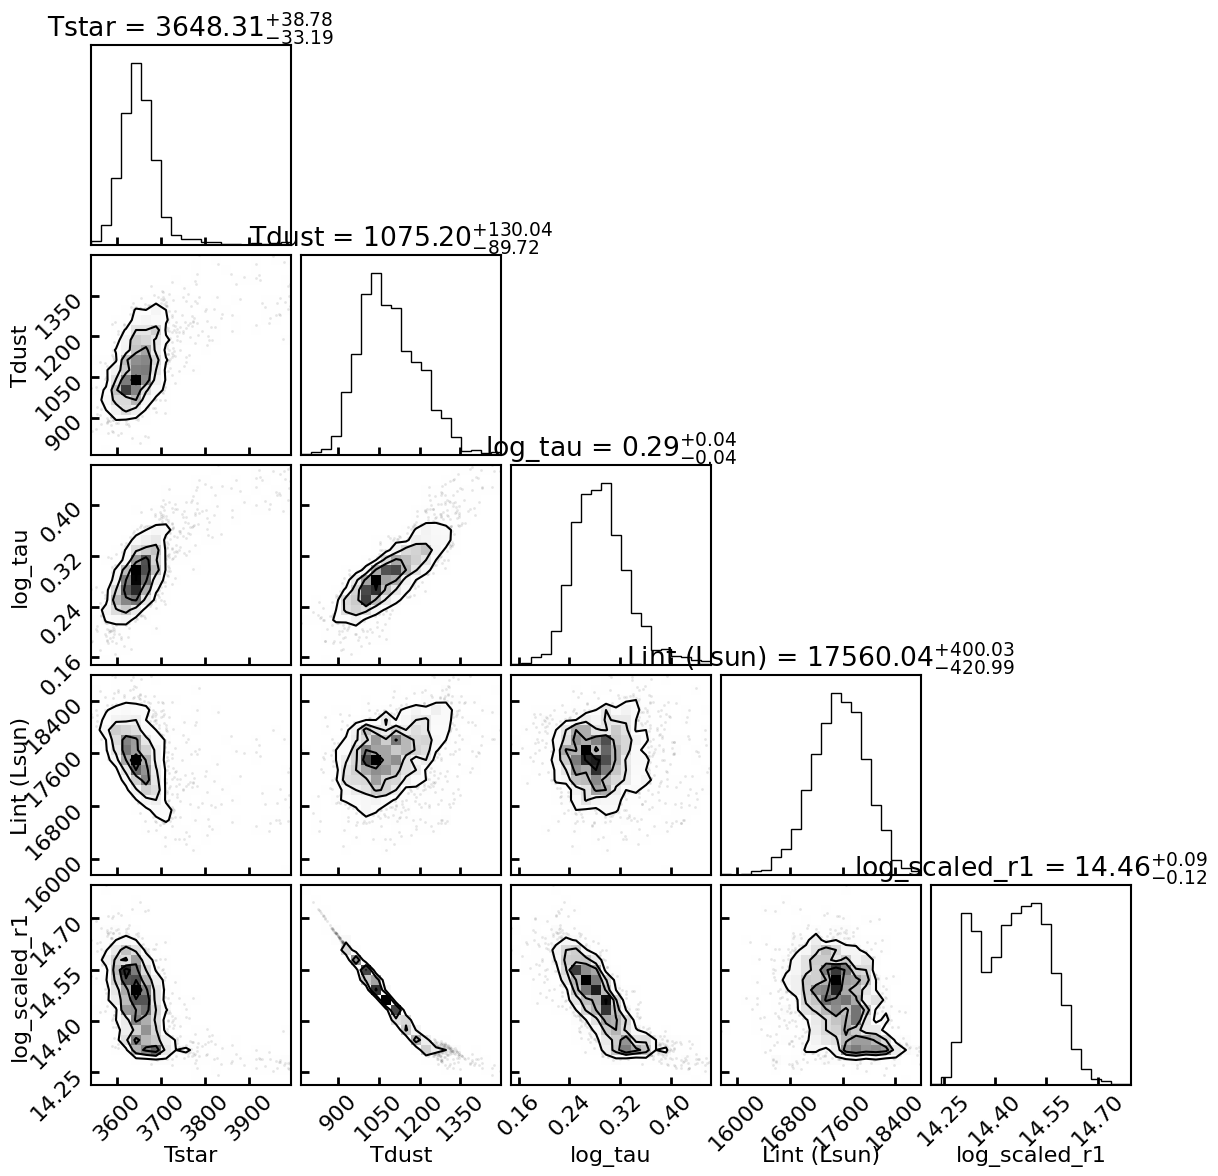

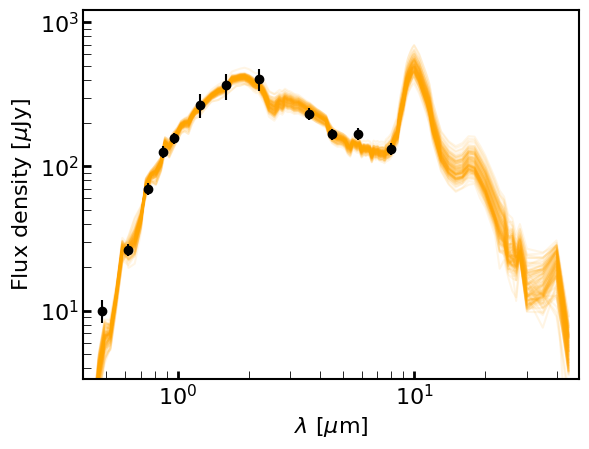

In [11]:
date = 'progenitor'
fnus = bb.fnu*1e6
fnuerrs = bb.fnuerr*1e6
wavs = bb.wavs_cm*1e4
wavs, fnus, fnuerrs = wavs[~np.isnan(fnus)], fnus[~np.isnan(fnus)], fnuerrs[~np.isnan(fnus)]
# Correct for extinction

sampler = run_mcmc(wavs, fnus, fnuerrs, dusty_model_wavs_spherex, net_spherex, r1_net_spherex, vary_ext=False, 
                   use_error_underestimation=False, 
                   plot_label=f'sed_{date}', nsteps=1000, labels=['Tstar','Tdust','log_tau'], 
                   par_min_vals=np.array([2500, 500, -1]), par_max_vals=np.array([4000, 1500, 1.0]), dist_mpc=bb.dist_mpc,
                    is_dusty_model_log_tau=True,predict_model=predict_dusty_model_simple, prior_func=uniform_prior_wtp19aalzlk)
